In [1]:
from google.colab import files
uploaded = files.upload()


Saving Dataset .csv to Dataset .csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [9]:
df = pd.read_csv('Dataset .csv')

In [10]:
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [11]:
df.shape

(9551, 21)

In [13]:
df.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='object')

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

In [15]:
df.isnull().sum()

,0
Restaurant ID,0
Restaurant Name,0
Country Code,0
City,0
Address,0
Locality,0
Locality Verbose,0
Longitude,0
Latitude,0
Cuisines,9


In [16]:
table_booking = df['Has Table booking'].value_counts()

table_booking

,count
Has Table booking,
No,8393
Yes,1158


In [17]:
table_booking_percentage = (
    df['Has Table booking']
    .value_counts(normalize=True)
    * 100
)

table_booking_percentage

,proportion
Has Table booking,
No,87.875615
Yes,12.124385


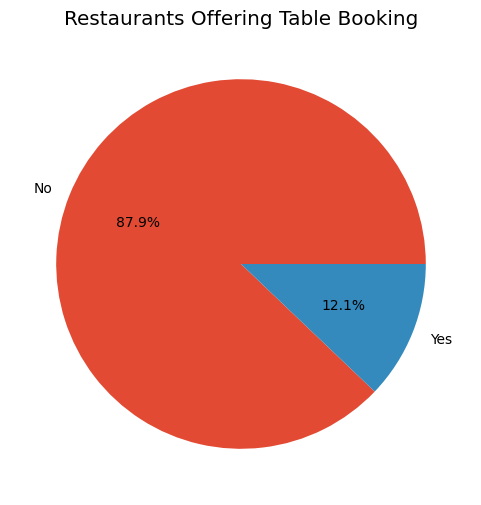

In [30]:
plt.figure(figsize=(6,6))

df['Has Table booking'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Restaurants Offering Table Booking')
plt.ylabel('')
plt.show()

In [19]:
online_delivery_percentage = (
    df['Has Online delivery']
    .value_counts(normalize=True)
    * 100
)

online_delivery_percentage

,proportion
Has Online delivery,
No,74.337766
Yes,25.662234


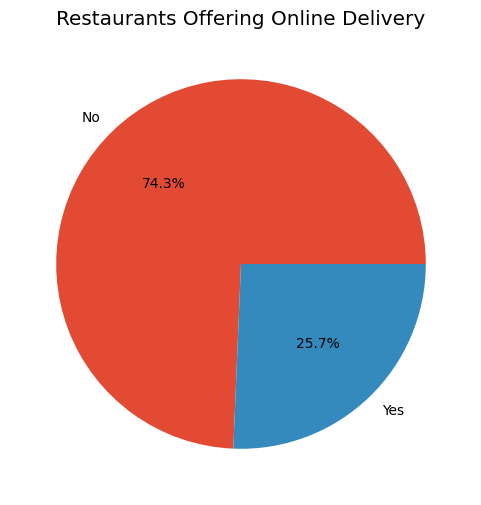

In [29]:
plt.figure(figsize=(6,6))

df['Has Online delivery'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Restaurants Offering Online Delivery')
plt.ylabel('')
plt.show()

In [21]:
df['Aggregate rating'].head()

,Aggregate rating
0,4.8
1,4.5
2,4.4
3,4.9
4,4.8


In [22]:
avg_rating = (
    df.groupby('Has Table booking')
    ['Aggregate rating']
    .mean()
)

avg_rating

,Aggregate rating
Has Table booking,
No,2.559359
Yes,3.441969


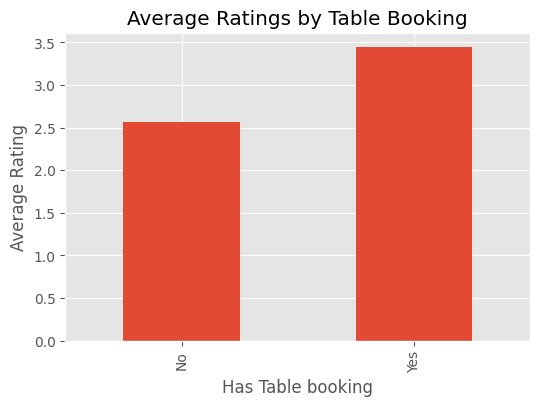

In [28]:
avg_rating.plot(
    kind='bar',
    figsize=(6,4)
)

plt.title('Average Ratings by Table Booking')
plt.ylabel('Average Rating')
plt.show()

In [24]:
df['Price range'].unique()

array([3, 4, 2, 1])

In [25]:
delivery_price = pd.crosstab(
    df['Price range'],
    df['Has Online delivery'],
    normalize='index'
) * 100

delivery_price

Has Online delivery,No,Yes
Price range,,
1,84.225923,15.774077
2,58.689367,41.310633
3,70.809659,29.190341
4,90.955631,9.044369


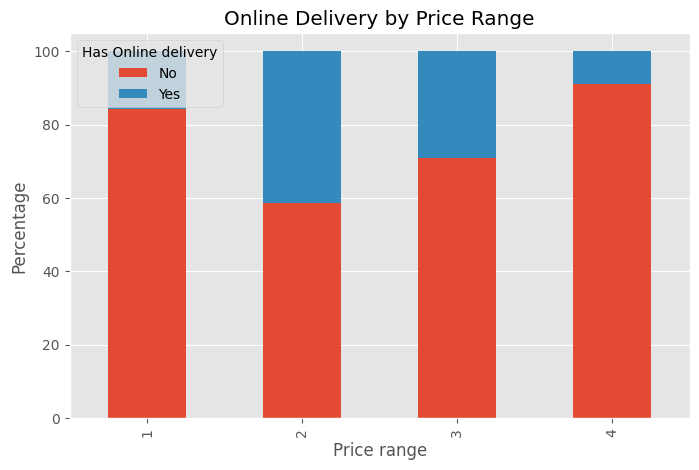

In [26]:
delivery_price.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)

plt.title('Online Delivery by Price Range')
plt.ylabel('Percentage')
plt.show()

Insights

1. Most restaurants do/do not provide table booking services.

2. Online delivery is available in a significant percentage of restaurants.

3. Restaurants with table booking generally receive higher ratings.

4. Online delivery is more common among certain price ranges.

5. Higher-priced restaurants tend to focus more on dine-in experiences than delivery.

Only 12.2% restaurants offer table booking.

25.%7 restaurants provide online delivery.

Restaurants with table booking have an average rating of 3.4 compared to 2.6 for those without.

Price range 2 restaurants show the highest online delivery availability.12.124385


Conclusion

The analysis shows that online delivery and table booking significantly influence restaurant operations and customer ratings. Restaurants offering table booking generally receive better ratings, while online delivery is more prevalent among mid-priced restaurants.